# 15.5 選中多位 expert 怎麼合併？


選出兩位expert後，模型下一層仍然只期待每個token有一個特徵向量。我們不能直接把兩個向量接起來，否則寬度會加倍；也不能只取最後完成的一位，否則前一位白算了。[top-k](https://birdhackor.github.io/tiny-perceptron-vlm/15.4.html)已回傳被選者與原比例；現在要沿特徵逐項加權相加，讓兩位的結果回到原本每個token的寬度。

取選中比例0.7、0.2，兩位輸出分別 `[1,0]` 與 `[0,2]`。直接用原比例相加，得到 `[0.7,0.4]`；若希望選中兩位的比例合計為一，就先除以0.9，變成 `7/9` 和 `2/9`，結果約 `[0.7778,0.4444]`。兩種規則都合理，但數值尺度不同，實作與解釋必須一致。本教材top-2採用重新正規化，top-1則保留原softmax比例，原因會在[router梯度](https://birdhackor.github.io/tiny-perceptron-vlm/15.7.html)說明。

下圖的兩條路都來自同一個token。各expert先產生兩項特徵，再乘上自己的比例，最後相同欄位相加。上下兩行顯示是否重新正規化的差別；它們都只有兩項輸出，沒有把寬度加倍。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

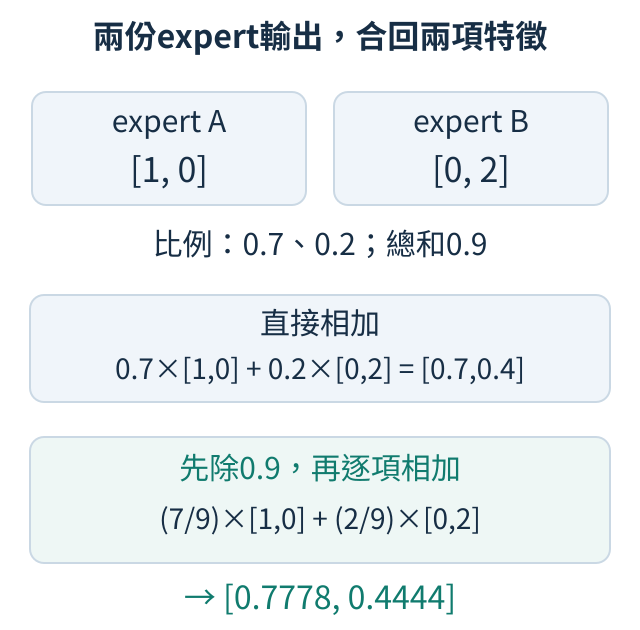

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-15-combine.svg")))

In [3]:
import torch

weights = torch.tensor([0.7, 0.2])
outputs = torch.tensor([[1.0, 0.0], [0.0, 2.0]])
normalized = weights / weights.sum()
print("直接合併", (weights @ outputs).round(decimals=4).tolist())
print("重算比例", normalized.round(decimals=4).tolist())
print("正規化合併", (normalized @ outputs).round(decimals=4).tolist())

直接合併 [0.699999988079071, 0.4000000059604645]
重算比例 [0.7778000235557556, 0.22220000624656677]
正規化合併 [0.7778000235557556, 0.44440001249313354]


`outputs`兩列代表兩位expert，各有兩項特徵。這次 `weights @ outputs`可看成簡短的加權和：第一項是 `0.7×1+0.2×0`，第二項是 `0.7×0+0.2×2`。它不是把token特徵轉到新的寬度，而是沿expert方向收集相同特徵。三行輸出應分別為 `[0.7,0.4]`、`[0.7778,0.2222]`、`[0.7778,0.4444]`。

正規化後的輸出落在兩位輸出的加權混合之間，但不保證接近原輸入。模型中的每位expert使用[前饋網路](https://birdhackor.github.io/tiny-perceptron-vlm/15.1.html)（Feed-Forward Network，FFN）處理特徵：先擴展特徵、做逐項非線性處理，再縮回原寬度。FFN本來就可以大幅改變特徵；是否再把原輸入加回，是外層[殘差路徑](https://birdhackor.github.io/tiny-perceptron-vlm/4.2.html)的責任。不要因為合併有加法，就把「expert結果之間相加」與「原輸入加回」混成同一步。

練習只交換outputs的兩列，保持weights不變。先手算正規化結果為 `[0.2222,1.5556]`，再重跑。這可以檢查你是否把每個比例對上正確expert；若比例與輸出一起交換，結果則不變。再思考只有一位時除以自身會得到什麼，先記住係數恆為1，後續便能理解為何影響router的學習。

<details>
<summary>選讀：來源、量測條件與原始實報</summary>

正式比較也沿用這個約定：top-2先除以選中總和，top-1保留原softmax比例。後者的原始加權形式可對照[Switch Transformer第2.1節、式1–2](https://arxiv.org/pdf/2101.03961v3)；本教材的top-2再正規化是另一個明示的選擇，不能把兩種係數當同一個算法。本次模型確實完成更新，但哪種規則更適合其他任務仍需要另設比較。

</details>
